In [2]:
import optuna
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/Backup/onion.csv")

df

,Date,price
0,2000-01-01 00:00:00,89.8
1,2000-02-01 00:00:00,77.4
2,2000-03-01 00:00:00,83.0
3,2000-04-01 00:00:00,81.6
4,2000-05-01 00:00:00,88.9
...,...,...
283,2023-08-01 00:00:00,233.9
284,2023-09-01 00:00:00,271.9
285,2023-10-01 00:00:00,343.4
286,2023-11-01 00:00:00,471.3


Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    288.000000
mean     229.182292
std      129.215875
min       77.400000
25%      139.525000
50%      201.800000
75%      273.375000
max      845.600000
Name: price, dtype: float64


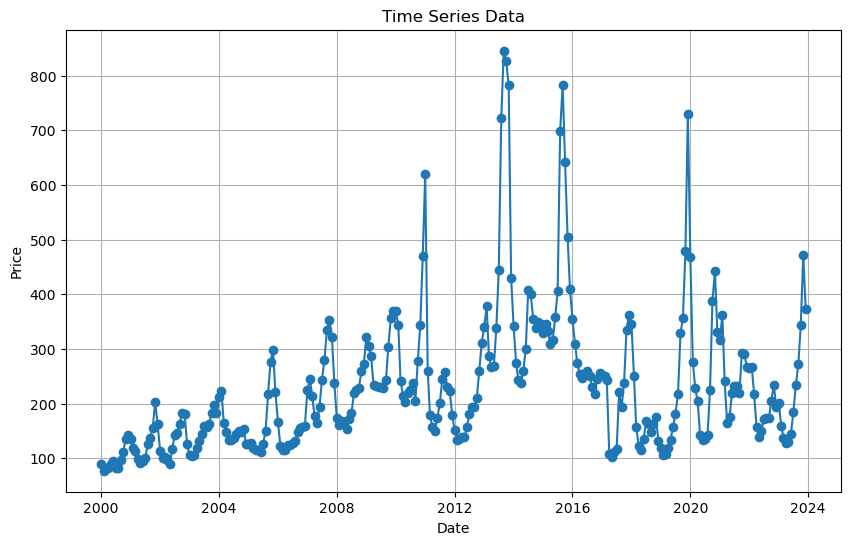

In [3]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


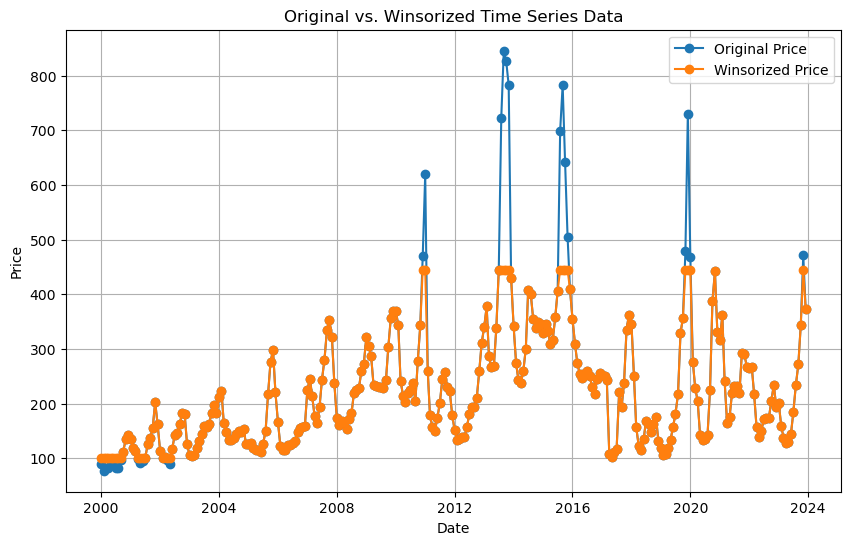

In [4]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
'''from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition
result = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months
detrended = df['price1'] - result.trend
seasonal = result.seasonal
residual = result.resid'''


"from statsmodels.tsa.seasonal import seasonal_decompose\n\n# Seasonal decomposition\nresult = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months\ndetrended = df['price1'] - result.trend\nseasonal = result.seasonal\nresidual = result.resid"

In [6]:
'''from sklearn.preprocessing import PowerTransformer

# Log transformation
df['Price_log'] = np.log(df['price1'])

# Box-Cox transformation
boxcox_transformer = PowerTransformer(method='box-cox')
df['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))

# Quantile transformation (e.g., Gaussian transformation)
quantile_transformer = PowerTransformer(method='yeo-johnson')
df['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))
'''

"from sklearn.preprocessing import PowerTransformer\n\n# Log transformation\ndf['Price_log'] = np.log(df['price1'])\n\n# Box-Cox transformation\nboxcox_transformer = PowerTransformer(method='box-cox')\ndf['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n\n# Quantile transformation (e.g., Gaussian transformation)\nquantile_transformer = PowerTransformer(method='yeo-johnson')\ndf['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n"

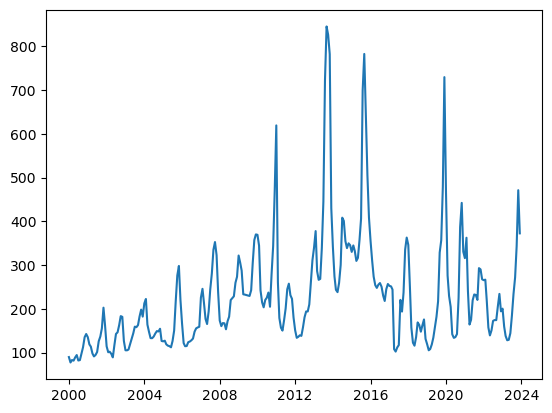

In [7]:
plt.plot(df['Date'],df['price'])

<Axes: >

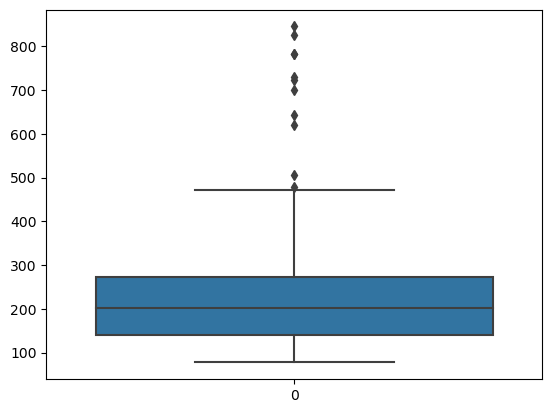

In [8]:
sn.boxplot(df['price'])

In [9]:
t=kpss(df['price'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_73038/1514378212.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price'],'ct')


(0.2919632085948914,
 0.01,
 9,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

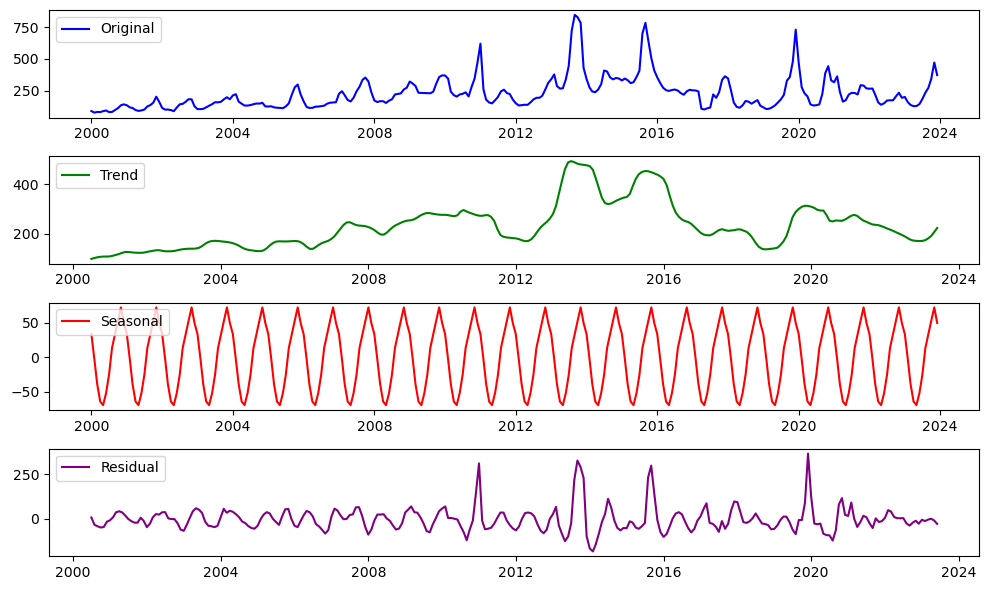

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [11]:
from scipy.stats import skew, kurtosis, shapiro

df=pd.read_csv("DATA/Backup/onion.csv")

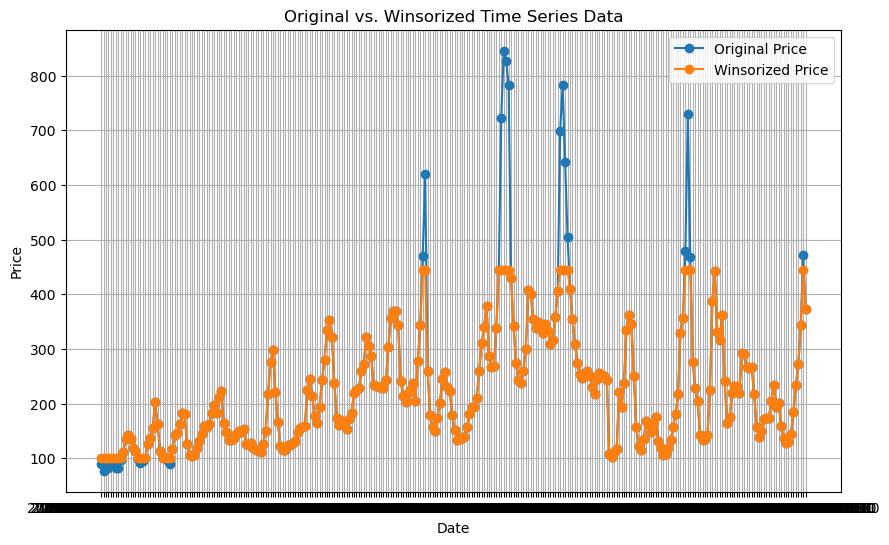

In [10]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df.pop('price')
df['price']=df.pop('price1')
df

,Date,price
0,2000-01-01 00:00:00,100.8
1,2000-02-01 00:00:00,100.8
2,2000-03-01 00:00:00,100.8
3,2000-04-01 00:00:00,100.8
4,2000-05-01 00:00:00,100.8
...,...,...
283,2023-08-01 00:00:00,233.9
284,2023-09-01 00:00:00,271.9
285,2023-10-01 00:00:00,343.4
286,2023-11-01 00:00:00,445.3


<Axes: >

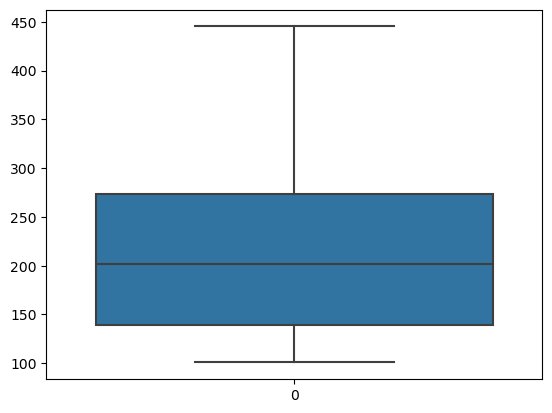

In [12]:
sn.boxplot(df['price'])

In [106]:
#df.pop('price')
#df['price']=df.pop('price1')
df1=df
df1

,Date,price
0,2000-01-01 00:00:00,166.9
1,2000-02-01 00:00:00,166.0
2,2000-03-01 00:00:00,166.6
3,2000-04-01 00:00:00,169.9
4,2000-05-01 00:00:00,171.0
...,...,...
283,2023-08-01 00:00:00,184.3
284,2023-09-01 00:00:00,187.0
285,2023-10-01 00:00:00,190.2
286,2023-11-01 00:00:00,191.4


In [12]:
skewness = skew(df['price'])
kurt = kurtosis(df['price'])

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p_value = shapiro(df['price'])

# Print the results
print("Skewness:", skewness)
print("Kurtosis:", kurt)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p_value)

Skewness: 2.142914773545168
Kurtosis: 6.224132559221536
Shapiro-Wilk Statistic: 0.8064097166061401
Shapiro-Wilk p-value: 3.0923245573427257e-18


In [14]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns

scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
#import matplotlib.pyplot as plt
#plt.plot(df['Date'],df['price'])


    

#dates_test, X_test, y_test = dates[q_80:], X[q_80:], y[q_80:]

#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [11]:
#dates
#X
#y

In [3]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values

In [4]:
df=pd.read_csv("DATA/Backup/onion.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)
df.pop('price')
df['price']=df.pop('price1')
shift=2
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

def objective(trial):
    # Define hyperparameters to tune
    lstm_units = trial.suggest_int('lstm_units', 32, 256)
    #gru_units = trial.suggest_int('gru_units', 32, 256)
    dense_units = trial.suggest_int('dense_units', 16, 128)
    #num_filters = trial.suggest_int('num_filters', 16, 128)
    #kernel_size = trial.suggest_int('kernel_size', 3, 7)
    #num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 3)
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5, 1e-4, 1e-3])

    # Construct the model
    model = Sequential([
        layers.Input((shift, 1)),
        #layers.LSTM(lstm_units),
        layers.Bidirectional(layers.LSTM(lstm_units)),
        #layers.GRU(gru_units),
        #layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
        #layers.MaxPooling1D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(1)
    ])
    '''
    model = Sequential()
    model.add(layers.Input((shift, 1)))
    for _ in range(num_lstm_layers):
        model.add(layers.LSTM(lstm_units, return_sequences=True))
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))'''
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    # Compile the model
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['mean_absolute_error'])

    # Train the model
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,callbacks=[early_stopping])

    # Evaluate the model on the validation set and return the validation loss
    loss = model.evaluate(X_val, y_val)[0]
    return loss


In [65]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2024-03-11 16:42:09,518] A new study created in memory with name: no-name-e0bd21fe-a2bb-4d21-9af8-3ca44632ec6a


Epoch 1/200
8/8 [==============================] - 1s 38ms/step - loss: 0.0290 - mean_absolute_error: 0.1310 - val_loss: 0.0215 - val_mean_absolute_error: 0.1069
Epoch 2/200
8/8 [==============================] - 0s 4ms/step - loss: 0.0079 - mean_absolute_error: 0.0718 - val_loss: 0.0157 - val_mean_absolute_error: 0.1084
Epoch 3/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0091 - mean_absolute_error: 0.0818 - val_loss: 0.0143 - val_mean_absolute_error: 0.0964
Epoch 4/200
8/8 [==============================] - 0s 4ms/step - loss: 0.0073 - mean_absolute_error: 0.0643 - val_loss: 0.0170 - val_mean_absolute_error: 0.1002
Epoch 5/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0060 - mean_absolute_error: 0.0577 - val_loss: 0.0139 - val_mean_absolute_error: 0.0953
Epoch 6/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0063 - mean_absolute_error: 0.0639 - val_loss: 0.0145 - val_mean_absolute_error: 0.0969
Epoch 7/200
8/8 [================

[I 2024-03-11 16:42:12,673] Trial 0 finished with value: 0.006706424057483673 and parameters: {'lstm_units': 168, 'dense_units': 33, 'learning_rate': 0.001}. Best is trial 0 with value: 0.006706424057483673.


Epoch 1/200
8/8 [==============================] - 1s 36ms/step - loss: 0.0413 - mean_absolute_error: 0.1652 - val_loss: 0.0600 - val_mean_absolute_error: 0.2051
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0365 - mean_absolute_error: 0.1523 - val_loss: 0.0541 - val_mean_absolute_error: 0.1915
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0322 - mean_absolute_error: 0.1402 - val_loss: 0.0486 - val_mean_absolute_error: 0.1778
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0283 - mean_absolute_error: 0.1286 - val_loss: 0.0437 - val_mean_absolute_error: 0.1648
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0249 - mean_absolute_error: 0.1184 - val_loss: 0.0394 - val_mean_absolute_error: 0.1523
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0219 - mean_absolute_error: 0.1093 - val_loss: 0.0355 - val_mean_absolute_error: 0.1408
Epoch 7/200
8/8 [================

[I 2024-03-11 16:42:14,952] Trial 1 finished with value: 0.014055074192583561 and parameters: {'lstm_units': 41, 'dense_units': 83, 'learning_rate': 0.0001}. Best is trial 0 with value: 0.006706424057483673.


...

1/1 [==============================] - 0s 9ms/step - loss: 0.0150 - mean_absolute_error: 0.0975


[I 2024-03-11 16:49:19,594] Trial 98 finished with value: 0.015030920505523682 and parameters: {'lstm_units': 135, 'dense_units': 35, 'learning_rate': 1e-05}. Best is trial 62 with value: 0.0055707604624331.


Epoch 1/200
8/8 [==============================] - 1s 42ms/step - loss: 0.0325 - mean_absolute_error: 0.1383 - val_loss: 0.0191 - val_mean_absolute_error: 0.1019
Epoch 2/200
8/8 [==============================] - 0s 6ms/step - loss: 0.0088 - mean_absolute_error: 0.0792 - val_loss: 0.0141 - val_mean_absolute_error: 0.1003
Epoch 3/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0065 - mean_absolute_error: 0.0638 - val_loss: 0.0170 - val_mean_absolute_error: 0.0995
Epoch 4/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0064 - mean_absolute_error: 0.0588 - val_loss: 0.0138 - val_mean_absolute_error: 0.0950
Epoch 5/200
8/8 [==============================] - 0s 5ms/step - loss: 0.0050 - mean_absolute_error: 0.0536 - val_loss: 0.0149 - val_mean_absolute_error: 0.0976
Epoch 6/200
8/8 [==============================] - 0s 6ms/step - loss: 0.0056 - mean_absolute_error: 0.0565 - val_loss: 0.0140 - val_mean_absolute_error: 0.0941
Epoch 7/200
8/8 [================

[I 2024-03-11 16:49:23,358] Trial 99 finished with value: 0.006096565630286932 and parameters: {'lstm_units': 256, 'dense_units': 61, 'learning_rate': 0.001}. Best is trial 62 with value: 0.0055707604624331.


Best hyperparameters: {'lstm_units': 198, 'dense_units': 36, 'learning_rate': 0.001}


In [66]:
best_params


{'lstm_units': 198, 'dense_units': 36, 'learning_rate': 0.001}

In [67]:
best_lstm_units = best_params['lstm_units']
#best_gru_units = best_params['gru_units']
best_dense_units = best_params['dense_units']
best_learning_rate = best_params['learning_rate']
#num_filters = best_params['num_filters']
#kernel_size = best_params['kernel_size']
#best_num_lstm_layers = best_params['num_lstm_layers']
#'''
model = Sequential([
    layers.Input((shift, 1)),
    #layers.LSTM(best_lstm_units),
    layers.Bidirectional(layers.LSTM(best_lstm_units)),
    #layers.GRU(best_gru_units),
    #layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
    #layers.MaxPooling1D(),
    layers.Flatten(),
    layers.Dense(best_dense_units, activation='relu'),
    layers.Dense(1)
])
'''
model = Sequential()
model.add(layers.Input((shift, 1)))
for _ in range(best_num_lstm_layers):
    model.add(layers.LSTM(best_lstm_units, return_sequences=True))
model.add(layers.Flatten())
model.add(layers.Dense(best_dense_units, activation='relu'))
model.add(layers.Dense(1))
#'''
# Compile the final model
model.compile(loss='mse', 
                optimizer=Adam(learning_rate=best_learning_rate),
                metrics=['mean_absolute_error'])

# Train the final model on the entire training data
h=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=300)
train_loss = model.evaluate(X_train, y_train, verbose=0)

    

Epoch 1/300
8/8 [==============================] - 1s 42ms/step - loss: 0.0281 - mean_absolute_error: 0.1264 - val_loss: 0.0148 - val_mean_absolute_error: 0.0985
Epoch 2/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0097 - mean_absolute_error: 0.0855 - val_loss: 0.0139 - val_mean_absolute_error: 0.0993
Epoch 3/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0069 - mean_absolute_error: 0.0650 - val_loss: 0.0173 - val_mean_absolute_error: 0.1004
Epoch 4/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0062 - mean_absolute_error: 0.0597 - val_loss: 0.0138 - val_mean_absolute_error: 0.0950
Epoch 5/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0053 - mean_absolute_error: 0.0564 - val_loss: 0.0142 - val_mean_absolute_error: 0.0961
Epoch 6/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0048 - mean_absolute_error: 0.0505 - val_loss: 0.0144 - val_mean_absolute_error: 0.0966
Epoch 7/300
8/8 [================

8/8 [==============================] - 0s 6ms/step - loss: 0.0018 - mean_absolute_error: 0.0286 - val_loss: 0.0063 - val_mean_absolute_error: 0.0609
Epoch 52/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0020 - mean_absolute_error: 0.0304 - val_loss: 0.0065 - val_mean_absolute_error: 0.0533
Epoch 53/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0020 - mean_absolute_error: 0.0298 - val_loss: 0.0064 - val_mean_absolute_error: 0.0547
Epoch 54/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0019 - mean_absolute_error: 0.0283 - val_loss: 0.0063 - val_mean_absolute_error: 0.0584
Epoch 55/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0018 - mean_absolute_error: 0.0292 - val_loss: 0.0062 - val_mean_absolute_error: 0.0539
Epoch 56/300
8/8 [==============================] - 0s 6ms/step - loss: 0.0019 - mean_absolute_error: 0.0290 - val_loss: 0.0066 - val_mean_absolute_error: 0.0587
Epoch 57/300
8/8 [=======================

8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0267 - val_loss: 0.0064 - val_mean_absolute_error: 0.0574
Epoch 102/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0276 - val_loss: 0.0060 - val_mean_absolute_error: 0.0561
Epoch 103/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0275 - val_loss: 0.0062 - val_mean_absolute_error: 0.0571
Epoch 104/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0269 - val_loss: 0.0064 - val_mean_absolute_error: 0.0580
Epoch 105/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0273 - val_loss: 0.0063 - val_mean_absolute_error: 0.0578
Epoch 106/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0268 - val_loss: 0.0064 - val_mean_absolute_error: 0.0575
Epoch 107/300
8/8 [=================

8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0266 - val_loss: 0.0067 - val_mean_absolute_error: 0.0593
Epoch 152/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0269 - val_loss: 0.0064 - val_mean_absolute_error: 0.0575
Epoch 153/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0276 - val_loss: 0.0064 - val_mean_absolute_error: 0.0574
Epoch 154/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0279 - val_loss: 0.0069 - val_mean_absolute_error: 0.0612
Epoch 155/300
8/8 [==============================] - 0s 4ms/step - loss: 0.0017 - mean_absolute_error: 0.0283 - val_loss: 0.0064 - val_mean_absolute_error: 0.0576
Epoch 156/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0276 - val_loss: 0.0068 - val_mean_absolute_error: 0.0590
Epoch 157/300
8/8 [=================

8/8 [==============================] - 0s 5ms/step - loss: 0.0020 - mean_absolute_error: 0.0315 - val_loss: 0.0075 - val_mean_absolute_error: 0.0667
Epoch 202/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0019 - mean_absolute_error: 0.0312 - val_loss: 0.0067 - val_mean_absolute_error: 0.0597
Epoch 203/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0020 - mean_absolute_error: 0.0312 - val_loss: 0.0077 - val_mean_absolute_error: 0.0679
Epoch 204/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0020 - mean_absolute_error: 0.0330 - val_loss: 0.0066 - val_mean_absolute_error: 0.0575
Epoch 205/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0018 - mean_absolute_error: 0.0312 - val_loss: 0.0070 - val_mean_absolute_error: 0.0599
Epoch 206/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0275 - val_loss: 0.0065 - val_mean_absolute_error: 0.0590
Epoch 207/300
8/8 [=================

8/8 [==============================] - 0s 5ms/step - loss: 0.0017 - mean_absolute_error: 0.0283 - val_loss: 0.0070 - val_mean_absolute_error: 0.0606
Epoch 252/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0268 - val_loss: 0.0067 - val_mean_absolute_error: 0.0577
Epoch 253/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0285 - val_loss: 0.0068 - val_mean_absolute_error: 0.0585
Epoch 254/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0269 - val_loss: 0.0067 - val_mean_absolute_error: 0.0591
Epoch 255/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0016 - mean_absolute_error: 0.0265 - val_loss: 0.0065 - val_mean_absolute_error: 0.0576
Epoch 256/300
8/8 [==============================] - 0s 5ms/step - loss: 0.0019 - mean_absolute_error: 0.0309 - val_loss: 0.0068 - val_mean_absolute_error: 0.0575
Epoch 257/300
8/8 [=================

Training Loss: [0.001537380157969892, 0.026653699576854706]
Testing Loss: [0.0023247511126101017, 0.03540598973631859]


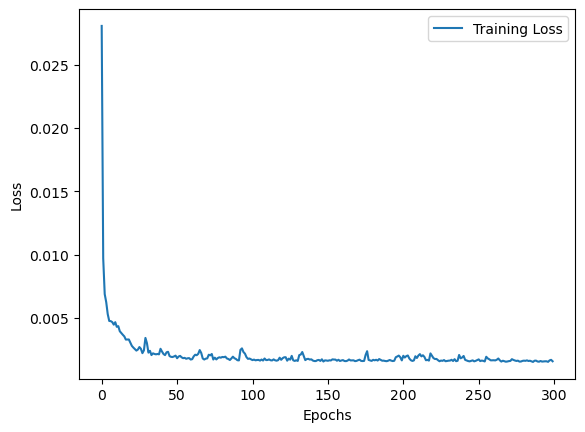

In [68]:
print(f'Training Loss: {train_loss}')
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')

plt.plot(h.history['loss'], label='Training Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

8/8 [==============================] - 0s 2ms/step


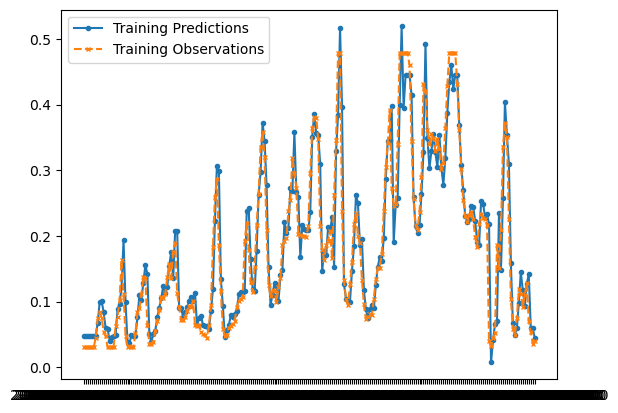

In [69]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_train, y_train, linestyle="--", marker='x', markersize=3)

##plt.plot(train_predictions)
##plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 11ms/step


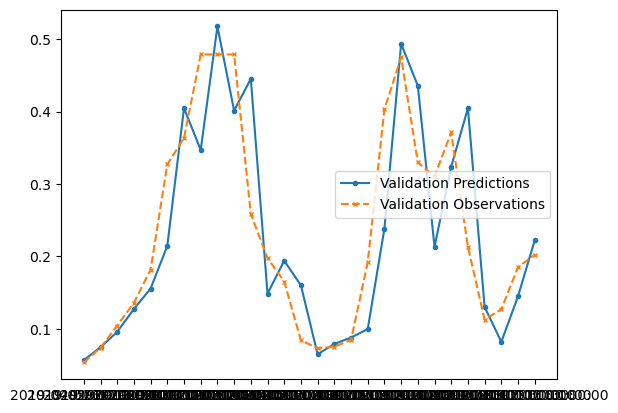

In [70]:
val_predictions = model.predict(X_val)#.flatten()

plt.plot(dates_val, val_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_val, y_val,linestyle="--", marker='x', markersize=3)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 12ms/step


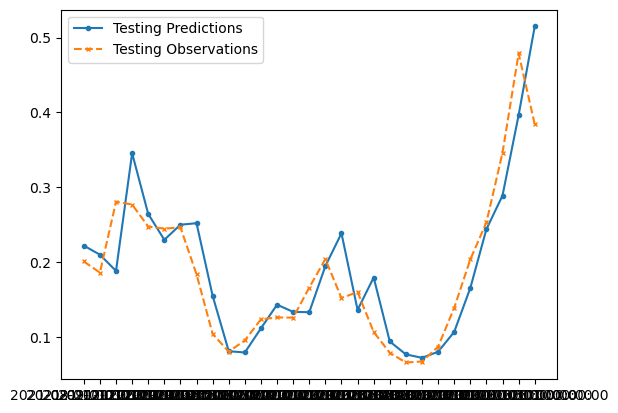

In [71]:
test_predictions = model.predict(X_test)#.flatten()

plt.plot(dates_test, test_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_test, y_test,linestyle="--", marker='x', markersize=3)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [72]:
#test_predictions

In [73]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [74]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 20.475366592407227
Training MSE: 907.2560424804688
Val MAE: 45.12941360473633
Val MSE: 3876.203125
Testing MAE: 27.198877334594727
Testing MSE: 1371.908447265625
30.120691
0.9017188442440118
62.25916
0.6639498833934709
37.039284
0.7606101713883902


In [58]:
model.save('onion_cnn')

INFO:tensorflow:Assets written to: onion_cnn/assets


INFO:tensorflow:Assets written to: onion_cnn/assets


In [62]:
import tensorflow as tf
m1=tf.keras.models.load_model('onion_cnn')
m1.layers[0].input_shape

(None, 3, 1)

In [48]:
df=pd.read_csv("DATA/Backup/onion.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)
df.pop('price')
df['price']=df.pop('price1')
shift=3
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [63]:
test_predictions = m1.predict(X_test)#.flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 31ms/step
0.7757681474328177


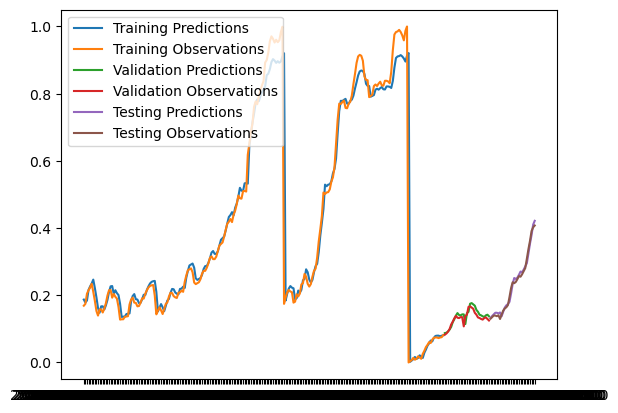

In [132]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'],loc='upper left')



In [81]:
n = 12  # Change this value to forecast more or fewer values
forecast = []
last_data = X[-1]  # Last X data point
for i in range(n):
    next_y = model.predict(last_data.reshape(1, X.shape[1], X.shape[2]))  # Predict next y
    forecast.append(next_y)
    last_data = np.append(last_data[1:], next_y)  # Shift data by 1 and append next_y
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
y_act=scaler.inverse_transform(np.array(y).reshape(-1, 1))

1/1 [==============================] - 0s 9ms/step


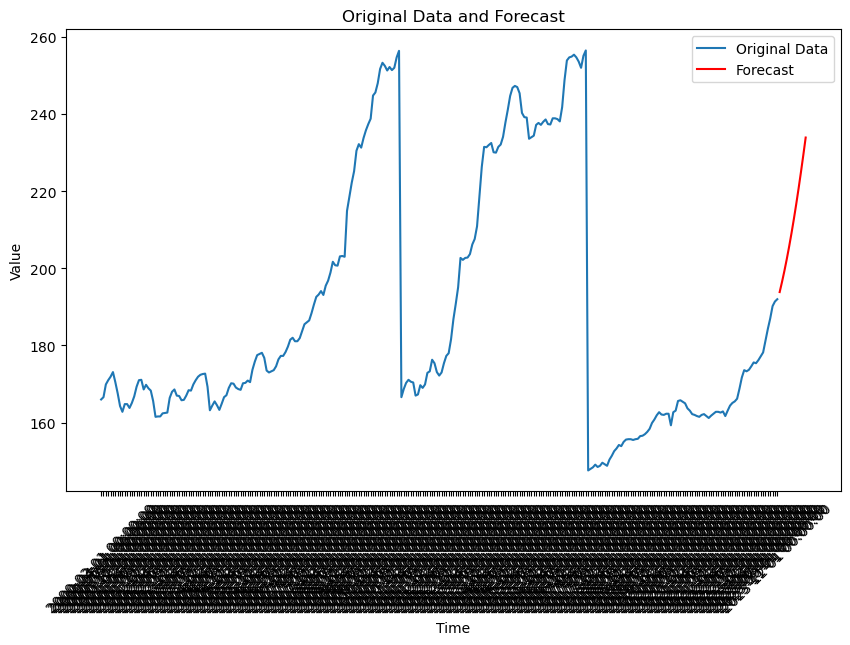

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(dates, y_act, label='Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data and Forecast')
plt.xticks(rotation=45)
plt.legend()

# Plot forecast
forecast_dates = np.arange(len(y), len(y) + n)
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.legend()

plt.show()